# Wavelet Source Detection for 3-D Spectral Cubes

Per-slice starlet (à trous IUWT) detection above diffuse emission.

**Strategy:**  
The starlet transform decomposes each spectral slice into fine detail bands (compact sources) and a coarse residual (diffuse emission). By thresholding only the fine scales we detect compact sources *above* the diffuse halo. Sources are found globally on the max-projected significance map, then measured per channel within Voronoi territories.

**Pipeline:**  
1. Per-channel significance maps (fine starlet scales, MAD noise, optional diffuse subtraction)  
2. Max-project → global significance  
3. `peak_local_max` → N source peaks  
4. Voronoi assignment → N territories  
5. Per-channel footprint = connected component at peak pixel within territory

## Imports

In [1]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path
from typing import NamedTuple

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass, label as nd_label
from skimage.measure import regionprops

## Multi-format cube loader

In [2]:
def load_cube(path: str | Path) -> np.ndarray:
    """Load a spectral cube from HDF5, FITS, .npy, or .npz.

    Always returns float32 (n_ch, H, W).
    """
    path = Path(path)
    suf = path.suffix.lower()

    if suf in (".h5", ".hdf5"):
        import h5py
        with h5py.File(path, "r") as f:
            cube = f["cube"][:].astype(np.float32)

    elif suf in (".fits", ".fit"):
        from astropy.io import fits
        with fits.open(path) as hdul:
            data = hdul[0].data
        if data is None:
            raise ValueError(f"No data in primary HDU of {path}")
        data = np.squeeze(data).astype(np.float32)
        if data.ndim == 2:
            data = data[np.newaxis]
        if data.ndim != 3:
            raise ValueError(f"Cannot interpret FITS array with shape {data.shape} as (n_ch,H,W)")
        cube = data

    elif suf == ".npy":
        cube = np.load(path).astype(np.float32)
        if cube.ndim == 2:
            cube = cube[np.newaxis]

    elif suf == ".npz":
        arch = np.load(path)
        if "cube" in arch:
            cube = arch["cube"].astype(np.float32)
        else:
            key = list(arch.keys())[0]
            cube = arch[key].astype(np.float32)

    else:
        raise ValueError(f"Unsupported file extension: {suf!r}. "
                         "Use .h5/.hdf5, .fits/.fit, .npy, or .npz")

    if cube.ndim != 3:
        raise ValueError(f"Loaded array has shape {cube.shape}; expected (n_ch, H, W)")

    np.nan_to_num(cube, copy=False, nan=0.0)
    return cube


def active_channels(cube: np.ndarray, threshold_frac: float = 0.05) -> list[int]:
    """Return indices of channels whose positive flux exceeds `threshold_frac` of the max.

    Uses only positive flux (clipped at zero) so noise-dominated channels don't inflate the total.
    """
    flux = np.nansum(np.clip(cube, 0.0, None), axis=(1, 2))
    thresh = threshold_frac * float(flux.max())
    return [int(i) for i in np.where(flux >= thresh)[0]]

In [3]:
CUBE_PATH = "/mnt/home/alahiry/data/mock_ifu/processed_cubes/clean_cube.npy"

cube = load_cube(CUBE_PATH)
n_ch, H, W = cube.shape
print(f"Cube shape: {cube.shape}  flux range [{cube.min():.3e}, {cube.max():.3e}]")

channel_list = active_channels(cube, threshold_frac=0.10)
print(f"Active channels: {len(channel_list)}  (ch {channel_list[0]}–{channel_list[-1]})")

Cube shape: (200, 500, 500)  flux range [-1.966e-19, 6.891e-02]
Active channels: 138  (ch 30–167)


In [4]:
from scipy.ndimage import gaussian_filter
from skimage.measure import label, regionprops
from skimage.feature import peak_local_max
import scarlet2 as sc

import numpy as np
import scarlet2 as sc

from skimage.measure import label, regionprops
from skimage.feature import peak_local_max

def wavelet_footprints_scarlet2(image, scales=4, k_sigma=2.3, use_scale=2, min_area=10, thresh=None):
    img = np.asarray(image, dtype=np.float32)
    sigma = 1.4826 * np.median(np.abs(img - np.median(img)))
    coeffs = np.asarray(sc.wavelets.starlet_transform(img, scales=scales), dtype=np.float32)

    print('\n', sigma,'\n')

    detect = np.zeros_like(coeffs)
    for i in range(coeffs.shape[0] - 1):
        detect[i] = np.where(np.abs(coeffs[i]) > (k_sigma * sigma), coeffs[i], 0.0)
    detect[-1] = coeffs[-1]
    detect[detect < 0] = 0

    scale_idx = int(np.clip(use_scale - 1, 0, detect.shape[0] - 1))
    plane = detect[scale_idx]
    effective_thresh = 0.1 * float(plane.max()) if thresh is None else thresh
    binary = plane > effective_thresh
    labeled = label(binary)
    regions = [r for r in regionprops(labeled, intensity_image=plane) if r.area >= min_area]

    peaks = []
    footprint_masks = []
    boxes = []
    for r in regions:
        y0, x0, y1, x1 = r.bbox
        patch = plane[y0:y1, x0:x1]
        if patch.size == 0:
            continue
        py, px = np.unravel_index(np.argmax(patch), patch.shape)
        yy = y0 + py
        xx = x0 + px
        peaks.append((yy, xx))
        footprint_masks.append(labeled == r.label)
        boxes.append((y0, x0, y1, x1))

    if len(peaks) == 0:
        fallback = peak_local_max(img, min_distance=3, num_peaks=1, exclude_border=False)
        if len(fallback) > 0:
            yy, xx = fallback[0]
            peaks = [(int(yy), int(xx))]
            mask = np.zeros_like(img, dtype=bool)
            y0 = max(0, int(yy) - 2)
            y1 = min(img.shape[0], int(yy) + 3)
            x0 = max(0, int(xx) - 2)
            x1 = min(img.shape[1], int(xx) + 3)
            mask[y0:y1, x0:x1] = True
            footprint_masks = [mask]
            boxes = [(y0, x0, y1, x1)]

    footprint_img = np.zeros_like(img, dtype=np.float32)
    for mask in footprint_masks:
        footprint_img = np.maximum(footprint_img, mask.astype(np.float32))

    return detect, coeffs, footprint_img, footprint_masks, peaks, boxes


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [5]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.animation as animation
import matplotlib.cm as cm

# Ensure scripts/wavelet is importable (notebook may run from repo root)
_scripts_wavelet = Path('scripts/wavelet')
if str(_scripts_wavelet) not in sys.path:
    sys.path.insert(0, str(_scripts_wavelet))

from flow_tracker import run_flow_tracker

# ── full pipeline: detect → flow → track → source-group ──────────────────
detections, flow_seq, tracks, sources = run_flow_tracker(
    cube,
    channel_list=channel_list,
    scales=6, k_sigma=5.0, use_scale=5, min_area=20,
    min_match_overlap=5, min_split_overlap=3, ghost_threshold=0.5,
    min_displacement=3.0,
)

# ── adapt to (ch, image, footprint_masks, peaks, boxes) tuples ───────────
# so the animation cells below work unchanged
frames    = [(d.channel, d.image, d.footprint_masks, d.peaks, d.boxes) for d in detections]
flow_data = list(flow_seq)   # already (ch_ref, ch_tgt, flow, joint_mask)

# ── source colour lookup ──────────────────────────────────────────────────
# Each mask object in track['masks'] is the same Python object that lives in
# frames; id() lets the animation loop resolve colour without extra bookkeeping.
mask_to_source: dict[int, int] = {}
for t in tracks:
    for ch, mask in t['masks'].items():
        mask_to_source[id(mask)] = t['source_id']

_src_cmap  = cm.get_cmap('tab10', max(len(sources), 1))
src_colors = {src['id']: _src_cmap(src['id'] % 10) for src in sources}

print(f"{len(tracks)} tracks  →  {len(sources)} sources")
for src in sources:
    r, g, b = [int(c * 255) for c in src_colors[src['id']][:3]]
    print(f"  source {src['id']}  #{r:02x}{g:02x}{b:02x}"
          f"  tracks={src['track_ids']}"
          f"  ch {src['channels'][0]}–{src['channels'][-1]}"
          f"  splits={src['split_events']}  merges={src['merge_events']}")


6 tracks  →  4 sources
  source 0  #1f77b4  tracks=[0, 4]  ch 30–167  splits=[56]  merges=[]
  source 1  #d62728  tracks=[1, 5]  ch 30–167  splits=[140]  merges=[]
  source 2  #e377c2  tracks=[2]  ch 30–167  splits=[]  merges=[]
  source 3  #17becf  tracks=[3]  ch 52–167  splits=[]  merges=[]


/tmp/ipykernel_2526907/855941744.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  _src_cmap  = cm.get_cmap('tab10', max(len(sources), 1))


In [6]:
# Flow is computed inside run_flow_tracker (cell above).
# flow_data is already available as a list of (ch_ref, ch_tgt, flow, joint_mask) tuples.

In [7]:
H, W = frames[0][1].shape
qs = 10  # quiver grid step (px)
ys = np.arange(0, H, qs)
xs = np.arange(0, W, qs)
Xq, Yq = np.meshgrid(xs, ys)
n_pts = Xq.size

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.subplots_adjust(wspace=0.05)

vmin = min(f[1].min() for f in frames)
vmax = max(f[1].max() for f in frames)

im0 = axes[0].imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax)
im1 = axes[1].imshow(frames[0][1], cmap='inferno', vmin=vmin, vmax=vmax)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
axes[0].set_title('Footprint contours (colour = source)', fontsize=13)
axes[1].set_title('Optical flow (TV-L1)', fontsize=13)
axes[0].set_xlabel('Pixel X'); axes[0].set_ylabel('Pixel Y')
axes[1].set_xlabel('Pixel X')
title = fig.suptitle('', fontsize=14)

quiv = axes[1].quiver(
    Xq.ravel(), Yq.ravel(), np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts),
    cmap='cool', angles='xy', scale_units='xy', scale=1,
    width=0.003, headwidth=4, headlength=5, alpha=0.9, clim=(0, 3),
)

contour_sets, text_artists = [], []

def _update_flow(frame_idx):
    ch_ref, ch_tgt, flow, joint_mask = flow_data[frame_idx]
    ch, img, footprint_masks, peaks, _ = frames[frame_idx]

    im0.set_data(img)
    im1.set_data(img)
    title.set_text(f'ch {ch_ref}→{ch_tgt}  |  joint mask: {joint_mask.sum()}px')

    for cs in contour_sets:
        cs.remove()
    contour_sets.clear()
    for a in text_artists:
        a.remove()
    text_artists.clear()

    for k, mask in enumerate(footprint_masks):
        sid   = mask_to_source.get(id(mask), -1)
        color = src_colors.get(sid, (1.0, 1.0, 1.0, 1.0))
        cs = axes[0].contour(mask.astype(float), [0.5], colors=[color], linewidths=1.2)
        contour_sets.append(cs)

    for k, (yy, xx) in enumerate(peaks):
        mask_k = footprint_masks[k] if k < len(footprint_masks) else None
        sid    = mask_to_source.get(id(mask_k), -1) if mask_k is not None else -1
        color  = src_colors.get(sid, (1.0, 1.0, 1.0, 1.0))
        ta = axes[0].text(xx, yy, f"S{sid}", color=color,
                          ha='center', va='center', fontsize=8, fontweight='bold')
        text_artists.append(ta)

    v_q = flow[0][ys[:, None], xs[None, :]].ravel()
    u_q = flow[1][ys[:, None], xs[None, :]].ravel()
    mag_q = np.hypot(u_q, v_q)
    peak_mag = float(mag_q.max())
    if peak_mag > 1e-6:
        amp = qs * 0.8 / peak_mag
        quiv.set_UVC(u_q * amp, v_q * amp, mag_q)
    else:
        quiv.set_UVC(np.zeros(n_pts), np.zeros(n_pts), np.zeros(n_pts))

    return [im0, im1, title]

ani = animation.FuncAnimation(fig, _update_flow, frames=len(flow_data), interval=800, blit=False)
ani.save('flow.gif', writer='pillow', fps=5)
plt.close(fig)
print('Saved flow.gif')

Saved flow.gif


In [ ]:
# Tracking and source grouping are done in the pipeline cell above.
# Print a per-track summary here for inspection.
n_kin = sum(1 for t in tracks if t['kinematic'])
print(f"{len(tracks)} tracks  ({n_kin} kinematic)  →  {len(sources)} sources\n")
for t in tracks:
    tag = "KINEMATIC" if t['kinematic'] else "static   "
    print(f"  [{tag}] track {t['id']:2d}  src={t['source_id']}"
          f"  disp={t['displacement']:.1f}px"
          f"  split_at={t['split_at']}"
          f"  split_from={t['split_from']}"
          f"  merge_into={t['merge_into']}")

6 tracks  (6 kinematic)  →  5 sources

  [KINEMATIC] track  0  src=0  disp=25.8px  split_at=[56]  split_from=None  merge_into=[]
  [KINEMATIC] track  1  src=1  disp=48.5px  split_at=[]  split_from=None  merge_into=[]
  [KINEMATIC] track  2  src=2  disp=28.4px  split_at=[]  split_from=None  merge_into=[]
  [KINEMATIC] track  3  src=3  disp=6.2px  split_at=[]  split_from=None  merge_into=[]
  [KINEMATIC] track  4  src=0  disp=0.0px  split_at=[]  split_from=0  merge_into=[]
  [KINEMATIC] track  5  src=4  disp=6.2px  split_at=[]  split_from=None  merge_into=[]


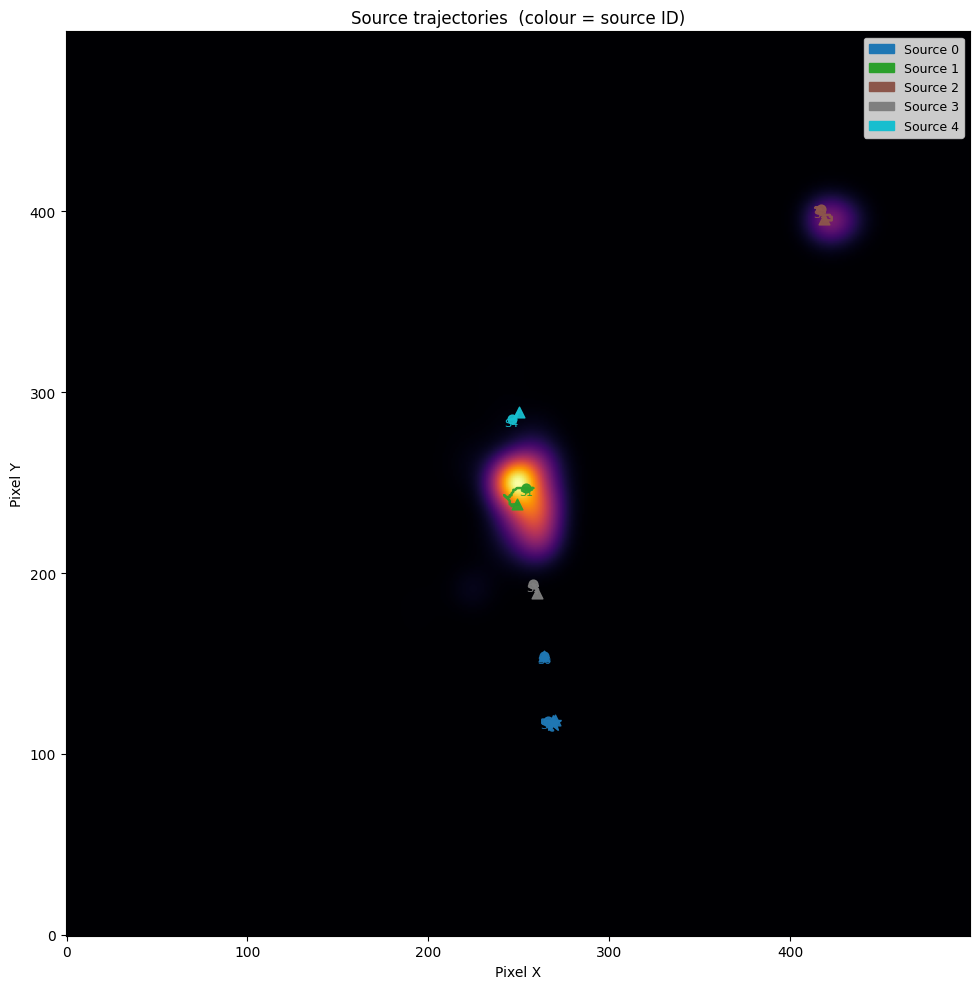

Saved trajectories.png
Saved kinematic_tracks.gif


In [ ]:
mean_img = cube[channel_list[len(channel_list)//2 - 2] : channel_list[len(channel_list)//2 + 3]].mean(axis=0)

# ── static trajectory plot — one colour per source ────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(mean_img, cmap='inferno', origin='lower')
ax.set_title('Source trajectories  (colour = source ID)', fontsize=12)
ax.set_xlabel('Pixel X'); ax.set_ylabel('Pixel Y')

for t in tracks:
    sid   = t['source_id']
    color = src_colors[sid]
    ys_t  = [p[1] for p in t['trajectory']]
    xs_t  = [p[2] for p in t['trajectory']]
    lw    = 1.8 if t['kinematic'] else 0.8
    alpha = 0.95 if t['kinematic'] else 0.4
    ax.plot(xs_t, ys_t, color=color, lw=lw, alpha=alpha)
    ax.scatter(xs_t[0],  ys_t[0],  s=40, color=color, zorder=5, marker='o', alpha=alpha)
    ax.scatter(xs_t[-1], ys_t[-1], s=60, color=color, zorder=5, marker='^', alpha=alpha)
    ax.text(xs_t[0], ys_t[0] - 5, f"S{sid}", color=color,
            fontsize=8, ha='center', va='bottom')
    for ch_sp in t['split_at']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_sp:
                ax.plot(sx, sy, marker='*', ms=12, color=color, zorder=6)
                break
    for ch_mg, _ in t['merge_into']:
        for ch, sy, sx in t['trajectory']:
            if ch == ch_mg:
                ax.plot(sx, sy, marker='D', ms=8, color=color, zorder=6, alpha=0.7)
                break

# Legend: one patch per source
patches = [mpatches.Patch(color=src_colors[s['id']], label=f"Source {s['id']}")
           for s in sources]
ax.legend(handles=patches, loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('trajectories.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved trajectories.png')

# ── animated GIF — channel-by-channel, contours + trajectory tails ────────
fig2, ax2 = plt.subplots(figsize=(10, 10))
ax2.set_xlabel('Pixel X'); ax2.set_ylabel('Pixel Y')
title2  = ax2.set_title('')
im_bg   = ax2.imshow(frames[0][1], cmap='inferno',
                     vmin=mean_img.min(), vmax=mean_img.max())

line_artists, scatter_artists, contour_sets2 = [], [], []

def _update_traj(fi):
    ch, img, footprint_masks, peaks, _ = frames[fi]
    im_bg.set_data(img)
    title2.set_text(f'Channel {ch}')

    for a in line_artists + scatter_artists:
        a.remove()
    line_artists.clear()
    scatter_artists.clear()
    for cs in contour_sets2:
        cs.remove()
    contour_sets2.clear()

    # footprint contours — coloured by source
    for mask in footprint_masks:
        sid   = mask_to_source.get(id(mask), -1)
        color = src_colors.get(sid, (1.0, 1.0, 1.0, 1.0))
        cs = ax2.contour(mask.astype(float), [0.5], colors=[color], linewidths=1.2)
        contour_sets2.append(cs)

    # trajectory tails up to current channel — coloured by source
    for t in tracks:
        sid   = t['source_id']
        color = src_colors[sid]
        past  = [(py, px) for tc, py, px in t['trajectory'] if tc <= ch]
        if not past:
            continue
        lw    = 2.0 if t['kinematic'] else 0.8
        alpha = 0.95 if t['kinematic'] else 0.4
        ln, = ax2.plot([p[1] for p in past], [p[0] for p in past],
                       color=color, lw=lw, alpha=alpha)
        sc  = ax2.scatter(past[-1][1], past[-1][0],
                          s=50, color=color, zorder=5, alpha=alpha)
        line_artists.append(ln)
        scatter_artists.append(sc)

    return [im_bg, title2]

ani2 = animation.FuncAnimation(fig2, _update_traj, frames=len(frames), interval=700, blit=False)
ani2.save('kinematic_tracks.gif', writer='pillow', fps=1)
plt.close(fig2)
print('Saved kinematic_tracks.gif')